In [1]:
# Load all the libraries
import warnings
warnings.filterwarnings('ignore')

import sys
import pathlib
from pathlib import Path
import pickle
import os
import numpy as np
import pandas as pd
from netCDF4 import Dataset as NetCDFFile 
import import_ipynb
from datetime import date, datetime, timedelta
import datetime as dt
# import oceans.sw_extras as swe
import gsw
import matplotlib.pyplot as plt
import timezonefinder, pytz
tf = timezonefinder.TimezoneFinder()

# Import SOCA ligh model funtions
import import_ipynb
from FUNCTIONS.OTHER_FUNCTIONS import rad_date, rad_LC_hour, derive_ZPD,find_MLD
from FUNCTIONS.PAR_ADJUSTED_FUNCTION import PAR_ADJUSTED_profiles
from FUNCTIONS.ED380_ADJUSTED_FUNCTION import ED380_ADJUSTED_profiles
from FUNCTIONS.ED412_ADJUSTED_FUNCTION import ED412_ADJUSTED_profiles
from FUNCTIONS.ED490_ADJUSTED_FUNCTION import ED490_ADJUSTED_profiles

In [105]:
# Force reload updated functions from notebooks
import importlib
import sys

# Remove cached modules to force reload
modules_to_reload = [
    'FUNCTIONS.PAR_ADJUSTED_FUNCTION',
    'FUNCTIONS.ED380_ADJUSTED_FUNCTION', 
    'FUNCTIONS.ED412_ADJUSTED_FUNCTION',
    'FUNCTIONS.ED490_ADJUSTED_FUNCTION',
    'FUNCTIONS.OTHER_FUNCTIONS'
]

for module in modules_to_reload:
    if module in sys.modules:
        del sys.modules[module]

# Now reimport with fresh modules
from FUNCTIONS.OTHER_FUNCTIONS import rad_date, rad_LC_hour, derive_ZPD,find_MLD
from FUNCTIONS.PAR_ADJUSTED_FUNCTION import PAR_ADJUSTED_profiles
from FUNCTIONS.ED380_ADJUSTED_FUNCTION import ED380_ADJUSTED_profiles
from FUNCTIONS.ED412_ADJUSTED_FUNCTION import ED412_ADJUSTED_profiles
from FUNCTIONS.ED490_ADJUSTED_FUNCTION import ED490_ADJUSTED_profiles

print("Functions successfully reloaded!")

Functions successfully reloaded!


### ct182

In [ ]:
## The inputs from excel file a sample file (INPUTS/inputs.xlsx) 
## The output file name as DAC_WMO_CYCLE_ED490.txt format this can change as per users choice

#######################################################################################
# define output path (WHERE YOU WANT TO SAVE THE OUTPUT FILES)
# PAR_OUT_PATH = pathlib.Path('/Users/renoshpr/Documents/BLUE_CLOUD/SOCA_CHL_2020/NOTEBOOK/PAR_ADJUSTED_MODEL_2022/PAR_ADJUSTED_Extraction_2023_51_depths/Output')
curr_work_dir = Path.cwd()
PAR_OUT_PATH_ct182 = (''.join([str(curr_work_dir),'/OUTPUTS/PAR/ct182']))
ED380_OUT_PATH_ct182 = (''.join([str(curr_work_dir),'/OUTPUTS/ED380/ct182']))
ED412_OUT_PATH_ct182 = (''.join([str(curr_work_dir),'/OUTPUTS/ED412/ct182']))
ED490_OUT_PATH_ct182 = (''.join([str(curr_work_dir),'/OUTPUTS/ED490/ct182']))

#######################################################################################
# READ INPUTS FROM EXCEL FILE
#
input_file_name = (''.join([str(curr_work_dir),'/SAT_MATCHUPS/ct182_satellite_matchups.csv']))
Inputs_ct182=pd.read_csv(str(input_file_name))

# print(Inputs)

for i in np.arange(len(Inputs_ct182)):
    # if i!=86:
    #     continue
    
    SEALTAG_NC_FILE = Inputs_ct182.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_ct182.PROFILE_NUM[i]
    RHO412 = Inputs_ct182.RRS412[i]
    RHO443 = Inputs_ct182.RRS443[i]
    RHO490 = Inputs_ct182.RRS490[i]
    RHO555 = Inputs_ct182.RRS555[i]
    RHO670 = Inputs_ct182.RRS670[i]
    PAR = Inputs_ct182.PAR[i]
    KD490 = Inputs_ct182.KD490[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    ED380_output_file = (''.join([str(ED380_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_ED380.txt']))
    ED412_output_file = (''.join([str(ED412_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_ED412.txt']))
    ED490_output_file = (''.join([str(ED490_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_ED490.txt']))
    
    #######################################################################################
    
    if os.path.isfile(SEALTAG_NC_FILE): # check Argo file exist
        # LOAD THE SEALTAG file
        #######################################################################################
        # ADD the path of the SEALTAG NC file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        # Read ProfileInfo excel file
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
    
        #######################################################################################
        ##### EXTRACTING TEMP SAL PRES same depths FROM NC ARGO FILE ##########################
        #######################################################################################
        pres_1 = NC.variables['PRES'][PROFILE-1,:]
        temp_1 = NC.variables['TEMP'][PROFILE-1,:]
        sal_1 = NC.variables['PSAL'][PROFILE-1,:]
        pres2 = pres_1.filled(fill_value=np.nan)
        temp2 = temp_1.filled(fill_value=np.nan)
        sal2 = sal_1.filled(fill_value=np.nan)
        
        # LAT = float(NC.variables['LATITUDE'][PROFILE-1])
        # LON = float(NC.variables['LONGITUDE'][PROFILE-1])
        LAT = float(profile_info.Lat[PROFILE-1])
        LON = float(profile_info.Lon[PROFILE-1])
        
        ########################################################################################
        # Declare output depths
        #Output daepth values 0, 5 10, 15, ... 250
        depth_output = np.linspace(0,250,51)
        #######################################################################################

        pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 10 good points in 0 to 250 m water column
        pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 15 good points in 0 to 250 m water column
        pres4=pres2[pres2<=50] # Light profile computed if T/S have at least 5 good points in 0 to 50 m water column
        if (len(pres3)>=15) & (len(pres4)>=5): # selected T/S profiles qualified above criterias
            #######################################################################################
            ##### EXTRACTING MLD ##################################################################
            #######################################################################################               
            # Derive Density Sigma0 and MLD from Temperature and Salinity profile
            # No need to change anything in this section by the user
            # SA = gsw.SA_from_SP(sal2, pres2, LON, LAT) # Abslute salinity from practical salinity
            # CT = gsw.CT_from_t(SA, temp2, pres2) # Conservative Temperature from in-situ sea water temperature
            # dens = gsw.density.sigma0(SA,CT) # Potential density
            # MLD_1 = find_MLD(Z=pres2, dens=dens, threshold = 0.03)
            # print('MLD is :', MLD_1,'m')
            
            # Read MLD from ProfileInfo excel file
            MLD_1 = -profile_info.MLD[PROFILE-1]
            # print('MLD is :', MLD_1,'m')
    
            #######################################################################################
            ##### EXTRACTING DOY FROM NC ARGO FILE ################################################
            #######################################################################################
            JULD = NC.variables['JULD'][PROFILE-1]
            # #Get day, month, year from juld
            ref_date = datetime(1950, 1, 1)
            date_prof = ref_date + timedelta(days=float(JULD))
            year_prof = date_prof.strftime('%Y')
            month_prof = date_prof.strftime('%m')
            day_prof = date_prof.strftime('%d')
            DOY = int(date_prof.strftime('%j'))
            # print(date_prof)
            # No need to change anything in this section by the user
            sin_doy = np.sin(rad_date(DOY))
            cos_doy = np.cos(rad_date(DOY))

            ########################################################################################################
            # Extract local time from the nc file and convert into radiance and then transform into Sine and Cosine
            ########################################################################################################
            timezone_str = tf.certain_timezone_at(lat=LAT, lng=LON)
            timezone = pytz.timezone(timezone_str)
            # date_prof is in GMT time scale
            LC = date_prof + timezone.utcoffset(date_prof) # +
            GMT_Hour = date_prof.strftime('%H')
            LC_Hour = LC.strftime('%H') 

            GMT_Hour_Min = date_prof.strftime('%H:%M')
            LC_Hour_Min = LC.strftime('%H:%M')  
            LC_Hour_Deci = (int(LC_Hour_Min[0:2]) + int(LC_Hour_Min[3:])/60)

            # LC_hour = 12
            sin_LC_hour = np.sin(rad_LC_hour(LC_Hour_Deci))
            cos_LC_hour = np.cos(rad_LC_hour(LC_Hour_Deci))
            ####################################################################################### 
            #######################################################################################
            # No need to change anything in this section by the user
            # HOW to use this function
    
            if(not np.isnan(MLD_1) and not np.isnan(PAR) and not np.isnan(KD490)and
                not np.isnan(RHO412) and not np.isnan(RHO443) and not np.isnan(RHO490) and
                not np.isnan(RHO555) and not np.isnan(RHO670)):
                PAR_ADJUSTED=PAR_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED380_ADJUSTED=ED380_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED412_ADJUSTED=ED412_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED490_ADJUSTED=ED490_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]                   
    
            else:
                PAR_ADJUSTED = np.nan
                ED380_ADJUSTED = np.nan
                ED412_ADJUSTED = np.nan
                ED490_ADJUSTED = np.nan
        else: # If temp/Sal criteria fails
            PAR_ADJUSTED = np.nan
            ED380_ADJUSTED = np.nan
            ED412_ADJUSTED = np.nan
            ED490_ADJUSTED = np.nan
        # else: # Temp and Sal not in delayed mode
        #     PAR_ADJUSTED = np.nan
        #     ED380_ADJUSTED = np.nan
        #     ED412_ADJUSTED = np.nan
        #     ED490_ADJUSTED = np.nan
    else: # If there is no BGC Argo file
        PAR_ADJUSTED = np.nan
        ED380_ADJUSTED = np.nan
        ED412_ADJUSTED = np.nan
        ED490_ADJUSTED = np.nan
              
    # #########################################################################################
    # ##########       
    db_par = {'depth': depth_output, 'PAR_ADJUSTED': PAR_ADJUSTED} 
    db_par = pd.DataFrame(db_par)
    db_par= db_par.round({'depth': 0, 'PAR_ADJUSTED': 4}) # Output adjusted to 4 decimal places
    
    db_ed380 = {'depth': depth_output, 'ED380_ADJUSTED': ED380_ADJUSTED} 
    db_ed380 = pd.DataFrame(db_ed380)
    db_ed380 = db_ed380.round({'depth': 0, 'ED380_ADJUSTED': 5}) # Output adjusted to 5 decimal places
    
    db_ed412 = {'depth': depth_output, 'ED412_ADJUSTED': ED412_ADJUSTED} 
    db_ed412 = pd.DataFrame(db_ed412)
    db_ed412 = db_ed412.round({'depth': 0, 'ED412_ADJUSTED': 5}) # Output adjusted to 5 decimal places
    
    db_ed490 = {'depth': depth_output, 'ED490_ADJUSTED': ED490_ADJUSTED} 
    db_ed490 = pd.DataFrame(db_ed490)
    db_ed490 = db_ed490.round({'depth': 0, 'ED490_ADJUSTED': 5}) # Output adjusted to 5 decimal places    
    
    ###########################################################################################
    db_par.to_csv(PAR_output_file, sep=',', index= False)
    db_ed380.to_csv(ED380_output_file, sep=',', index= False)   
    db_ed412.to_csv(ED412_output_file, sep=',', index= False)   
    db_ed490.to_csv(ED490_output_file, sep=',', index= False)   
       
    print(i)
    
    # Plot PAR_ADJUSTED profile down to 100 m for checking
    # plt.figure()
    # plt.plot(NC.variables['LIGHT'][PROFILE-1,:], -NC.variables['PRES'][PROFILE-1,:], 'ro')
    # plt.plot(db_par['PAR_ADJUSTED'], -db_par['depth'], '-o')
    # plt.xlabel('PAR_ADJUSTED (Ein m-2 s-1)')
    # plt.ylabel('Depth (m)')
    # plt.title('PAR_ADJUSTED Profile')     
    # plt.ylim(-100,0)
    # plt.legend(['SealTag Measured Light','Modeled PAR'])
##############################################################################################

In [85]:
# Create a comparison dataset between measured light and modeled light
# for all profiles and save as a csv file
from datetime import datetime

comparison_all_profiles_ct182 = pd.DataFrame()
for i in np.arange(len(Inputs_ct182)):
    SEALTAG_NC_FILE = Inputs_ct182.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_ct182.PROFILE_NUM[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_ct182),'/',str(Inputs_ct182.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    
    if os.path.isfile(SEALTAG_NC_FILE) and os.path.isfile(PAR_output_file):
        # LOAD THE SEALTAG file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
        profile_info_PhotoPhys = pd.read_excel(profile_info_file, sheet_name='PhotoPhys')
        
        # Load modeled PAR profile
        db_par = pd.read_csv(PAR_output_file)
        depth_modeled = db_par['depth'].values
        PAR_modeled = db_par['PAR_ADJUSTED'].values
        # Kd from modeled PAR
        kd_modeled_profile = -np.gradient(np.log(PAR_modeled), depth_modeled)
        kd_modeled = np.mean(kd_modeled_profile[1:20])  # Mean Kd from 1 to 50 m
        
        # Read measured light profile
        light_measured = NC.variables['LIGHT_DRK'][PROFILE-1,:]
        pres_measured = NC.variables['PRES'][PROFILE-1,:]
        light_measured = light_measured.filled(fill_value=np.nan)
        pres_measured = pres_measured.filled(fill_value=np.nan)
        # Kd from measured light
        kd_measured_profile = NC.variables['KD_LIGHT'][PROFILE-1,:]
        kd_measured = np.nanmean(kd_measured_profile[1:20])  # Mean Kd from 1 to 50 m, omit nans
        
        # Interpolate measured light to the modeled depths
        light_measured = np.interp(depth_modeled, pres_measured, light_measured, left=np.nan, right=np.nan)
        
        # Create a combined dataframe for comparison
        comparison_df = pd.DataFrame({
            'Depth_modeled': depth_modeled,
            'PAR_modeled': PAR_modeled,
            'Light_measured': light_measured
        })
        comparison_df['PAR_modeled_mean_1_20m'] = np.nanmean(PAR_modeled[1:20])
        comparison_df['Light_measured_mean_1_20m'] = np.nanmean(light_measured[1:20])
        comparison_df['Kd_modeled_1_20m'] = kd_modeled
        comparison_df['Kd_measured_1_20m'] = kd_measured
        comparison_df['Fluo_measured_mean_1_20m'] = np.nanmean(NC.variables['FLUO_DRK_NPQ'][PROFILE-1,1:21])
        comparison_df['SlopeFactor'] = profile_info_PhotoPhys['SlopeFactor_linfit'].values[PROFILE-1]
        comparison_df['Tag_ID'] = Inputs_ct182.TAG_ID[i]
        comparison_df['Profile'] = PROFILE
        comparison_df['SolarAlt'] = profile_info['SolarAlt'].values[PROFILE-1]
        comparison_df['Lat'] = profile_info['Lat'].values[PROFILE-1]
        comparison_df['Lon'] = profile_info['Lon'].values[PROFILE-1]
        comparison_df['Bathy'] = profile_info['Bathymetry_ETOPO'].values[PROFILE-1]
        comparison_df['DOY'] = int(pd.to_datetime(profile_info['Date'].values[PROFILE-1]).strftime("%j"))
        
        # Append to the overall comparison dataset
        comparison_all_profiles_ct182 = pd.concat([comparison_all_profiles_ct182, comparison_df], ignore_index=True)
        
# Set all measured values nan that are less than 10^-9
comparison_all_profiles_ct182.loc[comparison_all_profiles_ct182['Light_measured'] < 1e-9, 'Light_measured'] = np.nan

# Export the comparison dataset to CSV
comparison_output_file = (''.join(['Comparison_Modeled_vs_Measured_Light_All_Profiles_ct182.csv']))
comparison_all_profiles_ct182.to_csv(comparison_output_file, index=False)

In [ ]:
# Plot the first 15 profiles of modeled vs measured light
plt.figure(figsize=(15,6))
for j in range(15):
    example_tag = Inputs_ct182.TAG_ID[j]
    example_profile = Inputs_ct182.PROFILE_NUM[j]
    example_data = comparison_all_profiles_ct182[(comparison_all_profiles_ct182['Tag_ID'] == example_tag) &
                                            (comparison_all_profiles_ct182['Profile'] == example_profile)]
    plt.subplot(3, 5, j+1)
    plt.plot(example_data['PAR_modeled'], -example_data['Depth_modeled'], '-o')
    plt.plot(example_data['Light_measured'], -example_data['Depth_modeled'], 'ro')
    # plt.plot(example_data['Light_measured_fitted_interp'], -example_data['Depth_modeled'], 'g-', linewidth=2)
    plt.xlabel('Light (Ein m-2 s-1)')
    plt.ylabel('Depth (m)')
    # plt.title('{}, Profile: {}'.format(example_tag, example_profile))     
    plt.ylim(-100,0)
    # plt.legend(['Modeled PAR','Measured Light'])
    # Show y labels and ticks only on left plots
    if j % 5 != 0:
        plt.ylabel('')
        # plt.yticks([])
    # Show x labels only on bottom plots
    if j < 5:
        plt.xlabel('')
        # plt.xticks([])

Text(0.5, 1.0, 'SealTag Profiles Colored by Solar Altitude')

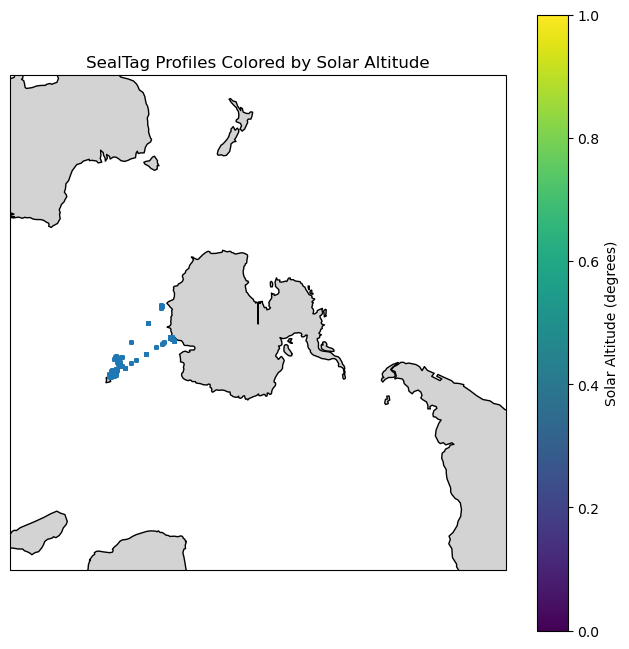

In [32]:
# Plot a polar stereographic map of all profiles colored by Solar Altitude
plt.figure(figsize=(8,8))
import cartopy.crs as ccrs
import cartopy.feature as cfeature
ax = plt.axes(projection=ccrs.Stereographic(central_latitude=-90, central_longitude=180))
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgray')
sc = ax.scatter(comparison_all_profiles_ct182['Lon'], comparison_all_profiles_ct182['Lat'], transform=ccrs.PlateCarree(),s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.title('SealTag Profiles Colored by Solar Altitude')

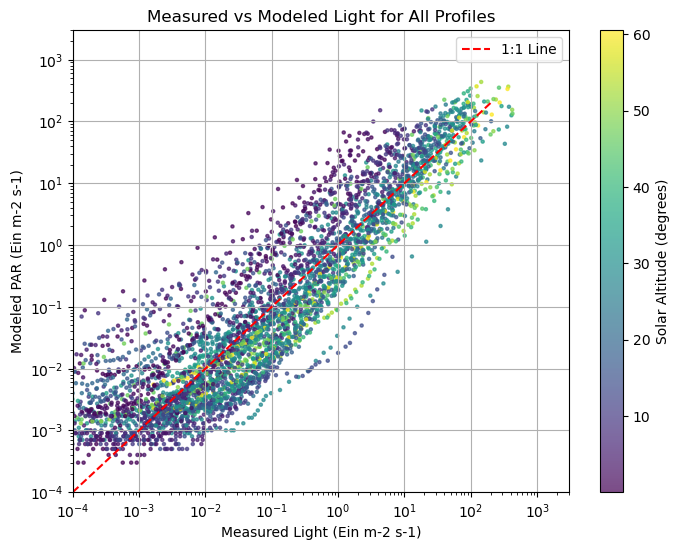

Light Linear Model: Slope=0.830, Intercept=3.114, R2=0.511, RMSE=19.9860, p=0.715


In [56]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Light_measured'], comparison_all_profiles_ct182['PAR_modeled'], c=comparison_all_profiles_ct182['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 3000)
plt.ylim(1e-4, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
from sklearn.metrics import r2_score, mean_squared_error
import math
light_measured = comparison_all_profiles_ct182['Light_measured'].values
par_modeled = comparison_all_profiles_ct182['PAR_modeled'].values
# Remove nans
valid_idx = ~np.isnan(light_measured) & ~np.isnan(par_modeled)
light_measured = light_measured[valid_idx]
par_modeled = par_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(light_measured, par_modeled, 1)
par_modeled_pred = slope * light_measured + intercept
r2 = r2_score(par_modeled, par_modeled_pred)
rmse = math.sqrt(mean_squared_error(par_modeled, par_modeled_pred))
p_value = np.corrcoef(light_measured, par_modeled)[0,1]
print('Light Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

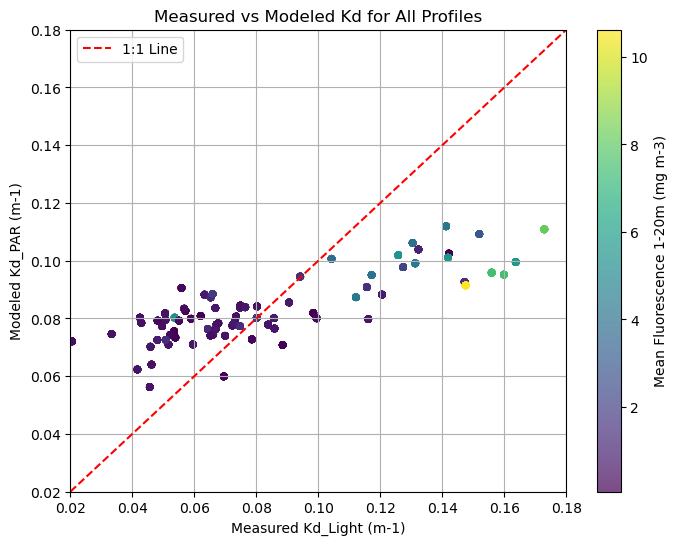

Kd Linear Model: Slope=0.236, Intercept=0.063, R2=0.579, RMSE=0.0077 m-1, p=0.761


In [34]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Kd_measured_1_20m'], comparison_all_profiles_ct182['Kd_modeled_1_20m'], c=comparison_all_profiles_ct182['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled Kd
from sklearn.metrics import r2_score, mean_squared_error
import math
kd_measured = comparison_all_profiles_ct182['Kd_measured_1_20m'].values
kd_modeled = comparison_all_profiles_ct182['Kd_modeled_1_20m'].values
# Remove nans
valid_idx = ~np.isnan(kd_measured) & ~np.isnan(kd_modeled)
kd_measured = kd_measured[valid_idx]
kd_modeled = kd_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(kd_measured, kd_modeled, 1)
kd_modeled_pred = slope * kd_measured + intercept
r2 = r2_score(kd_modeled, kd_modeled_pred)
rmse = math.sqrt(mean_squared_error(kd_modeled, kd_modeled_pred))
p_value = np.corrcoef(kd_measured, kd_modeled)[0,1]
print('Kd Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f} m-1, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

### Pre-2023 tags

In [ ]:
## The inputs from excel file a sample file (INPUTS/inputs.xlsx) 
## The output file name as DAC_WMO_CYCLE_ED490.txt format this can change as per users choice

#######################################################################################
# define output path (WHERE YOU WANT TO SAVE THE OUTPUT FILES)
# PAR_OUT_PATH = pathlib.Path('/Users/renoshpr/Documents/BLUE_CLOUD/SOCA_CHL_2020/NOTEBOOK/PAR_ADJUSTED_MODEL_2022/PAR_ADJUSTED_Extraction_2023_51_depths/Output')
curr_work_dir = Path.cwd()
PAR_OUT_PATH_pre2023 = (''.join([str(curr_work_dir),'/OUTPUTS/PAR/pre2023']))
ED380_OUT_PATH_pre2023 = (''.join([str(curr_work_dir),'/OUTPUTS/ED380/pre2023']))
ED412_OUT_PATH_pre2023 = (''.join([str(curr_work_dir),'/OUTPUTS/ED412/pre2023']))
ED490_OUT_PATH_pre2023 = (''.join([str(curr_work_dir),'/OUTPUTS/ED490/pre2023']))

#######################################################################################
# READ INPUTS FROM EXCEL FILE
#
input_file_name = (''.join([str(curr_work_dir),'/SAT_MATCHUPS/2018_2023_satellite_matchups.csv']))
Inputs_pre2023=pd.read_csv(str(input_file_name))

# print(Inputs)

for i in np.arange(len(Inputs_pre2023)):
    # if i!=86:
    #     continue
    
    SEALTAG_NC_FILE = Inputs_pre2023.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_pre2023.PROFILE_NUM[i]
    RHO412 = Inputs_pre2023.RRS412[i]
    RHO443 = Inputs_pre2023.RRS443[i]
    RHO490 = Inputs_pre2023.RRS490[i]
    RHO555 = Inputs_pre2023.RRS555[i]
    RHO670 = Inputs_pre2023.RRS670[i]
    PAR = Inputs_pre2023.PAR[i]
    KD490 = Inputs_pre2023.KD490[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_pre2023),'/',str(Inputs_pre2023.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    ED380_output_file = (''.join([str(ED380_OUT_PATH_pre2023),'/',str(Inputs_pre2023.TAG_ID[i]),'_',str(PROFILE),'_ED380.txt']))
    ED412_output_file = (''.join([str(ED412_OUT_PATH_pre2023),'/',str(Inputs_pre2023.TAG_ID[i]),'_',str(PROFILE),'_ED412.txt']))
    ED490_output_file = (''.join([str(ED490_OUT_PATH_pre2023),'/',str(Inputs_pre2023.TAG_ID[i]),'_',str(PROFILE),'_ED490.txt']))
    
    #######################################################################################
    
    if os.path.isfile(SEALTAG_NC_FILE): # check Argo file exist
        # LOAD THE SEALTAG file
        #######################################################################################
        # ADD the path of the SEALTAG NC file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        # Read ProfileInfo excel file
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
    
        #######################################################################################
        ##### EXTRACTING TEMP SAL PRES same depths FROM NC ARGO FILE ##########################
        #######################################################################################
        pres_1 = NC.variables['PRES'][PROFILE-1,:]
        temp_1 = NC.variables['TEMP'][PROFILE-1,:]
        sal_1 = NC.variables['PSAL'][PROFILE-1,:]
        pres2 = pres_1.filled(fill_value=np.nan)
        temp2 = temp_1.filled(fill_value=np.nan)
        sal2 = sal_1.filled(fill_value=np.nan)
        
        # LAT = float(NC.variables['LATITUDE'][PROFILE-1])
        # LON = float(NC.variables['LONGITUDE'][PROFILE-1])
        LAT = float(profile_info.Lat[PROFILE-1])
        LON = float(profile_info.Lon[PROFILE-1])
        
        ########################################################################################
        # Declare output depths
        #Output daepth values 0, 5 10, 15, ... 250
        depth_output = np.linspace(0,250,51)
        #######################################################################################

        pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 10 good points in 0 to 250 m water column
        pres3=pres2[pres2<=250] # Light profile computed if T/S have at least 15 good points in 0 to 250 m water column
        pres4=pres2[pres2<=50] # Light profile computed if T/S have at least 5 good points in 0 to 50 m water column
        if (len(pres3)>=15) & (len(pres4)>=5): # selected T/S profiles qualified above criterias
            #######################################################################################
            ##### EXTRACTING MLD ##################################################################
            #######################################################################################               
            # Derive Density Sigma0 and MLD from Temperature and Salinity profile
            # No need to change anything in this section by the user
            # SA = gsw.SA_from_SP(sal2, pres2, LON, LAT) # Abslute salinity from practical salinity
            # CT = gsw.CT_from_t(SA, temp2, pres2) # Conservative Temperature from in-situ sea water temperature
            # dens = gsw.density.sigma0(SA,CT) # Potential density
            # MLD_1 = find_MLD(Z=pres2, dens=dens, threshold = 0.03)
            # print('MLD is :', MLD_1,'m')
            
            # Read MLD from ProfileInfo excel file
            MLD_1 = -profile_info.MLD[PROFILE-1]
            # print('MLD is :', MLD_1,'m')
    
            #######################################################################################
            ##### EXTRACTING DOY FROM NC ARGO FILE ################################################
            #######################################################################################
            JULD = NC.variables['JULD'][PROFILE-1]
            # #Get day, month, year from juld
            ref_date = datetime(1950, 1, 1)
            date_prof = ref_date + timedelta(days=float(JULD))
            year_prof = date_prof.strftime('%Y')
            month_prof = date_prof.strftime('%m')
            day_prof = date_prof.strftime('%d')
            DOY = int(date_prof.strftime('%j'))
            # print(date_prof)
            # No need to change anything in this section by the user
            sin_doy = np.sin(rad_date(DOY))
            cos_doy = np.cos(rad_date(DOY))

            ########################################################################################################
            # Extract local time from the nc file and convert into radiance and then transform into Sine and Cosine
            ########################################################################################################
            timezone_str = tf.certain_timezone_at(lat=LAT, lng=LON)
            timezone = pytz.timezone(timezone_str)
            # date_prof is in GMT time scale
            LC = date_prof + timezone.utcoffset(date_prof) # +
            GMT_Hour = date_prof.strftime('%H')
            LC_Hour = LC.strftime('%H') 

            GMT_Hour_Min = date_prof.strftime('%H:%M')
            LC_Hour_Min = LC.strftime('%H:%M')  
            LC_Hour_Deci = (int(LC_Hour_Min[0:2]) + int(LC_Hour_Min[3:])/60)

            # LC_hour = 12
            sin_LC_hour = np.sin(rad_LC_hour(LC_Hour_Deci))
            cos_LC_hour = np.cos(rad_LC_hour(LC_Hour_Deci))
            ####################################################################################### 
            #######################################################################################
            # No need to change anything in this section by the user
            # HOW to use this function
    
            if(not np.isnan(MLD_1) and not np.isnan(PAR) and not np.isnan(KD490)and
                not np.isnan(RHO412) and not np.isnan(RHO443) and not np.isnan(RHO490) and
                not np.isnan(RHO555) and not np.isnan(RHO670)):
                PAR_ADJUSTED=PAR_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED380_ADJUSTED=ED380_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED412_ADJUSTED=ED412_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                ED490_ADJUSTED=ED490_ADJUSTED_profiles(PAR=PAR, MLD=MLD_1, ZPD=derive_ZPD(float(KD490)), RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                    RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                    cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                    temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]                   
    
            else:
                PAR_ADJUSTED = np.nan
                ED380_ADJUSTED = np.nan
                ED412_ADJUSTED = np.nan
                ED490_ADJUSTED = np.nan
        else: # If temp/Sal criteria fails
            PAR_ADJUSTED = np.nan
            ED380_ADJUSTED = np.nan
            ED412_ADJUSTED = np.nan
            ED490_ADJUSTED = np.nan
        # else: # Temp and Sal not in delayed mode
        #     PAR_ADJUSTED = np.nan
        #     ED380_ADJUSTED = np.nan
        #     ED412_ADJUSTED = np.nan
        #     ED490_ADJUSTED = np.nan
    else: # If there is no BGC Argo file
        PAR_ADJUSTED = np.nan
        ED380_ADJUSTED = np.nan
        ED412_ADJUSTED = np.nan
        ED490_ADJUSTED = np.nan
              
    # #########################################################################################
    # ##########       
    db_par = {'depth': depth_output, 'PAR_ADJUSTED': PAR_ADJUSTED} 
    db_par = pd.DataFrame(db_par)
    db_par= db_par.round({'depth': 0, 'PAR_ADJUSTED': 4}) # Output adjusted to 4 decimal places
    
    db_ed380 = {'depth': depth_output, 'ED380_ADJUSTED': ED380_ADJUSTED} 
    db_ed380 = pd.DataFrame(db_ed380)
    db_ed380 = db_ed380.round({'depth': 0, 'ED380_ADJUSTED': 5}) # Output adjusted to 5 decimal places
    
    db_ed412 = {'depth': depth_output, 'ED412_ADJUSTED': ED412_ADJUSTED} 
    db_ed412 = pd.DataFrame(db_ed412)
    db_ed412 = db_ed412.round({'depth': 0, 'ED412_ADJUSTED': 5}) # Output adjusted to 5 decimal places
    
    db_ed490 = {'depth': depth_output, 'ED490_ADJUSTED': ED490_ADJUSTED} 
    db_ed490 = pd.DataFrame(db_ed490)
    db_ed490 = db_ed490.round({'depth': 0, 'ED490_ADJUSTED': 5}) # Output adjusted to 5 decimal places    
    
    ###########################################################################################
    db_par.to_csv(PAR_output_file, sep=',', index= False)
    db_ed380.to_csv(ED380_output_file, sep=',', index= False)   
    db_ed412.to_csv(ED412_output_file, sep=',', index= False)   
    db_ed490.to_csv(ED490_output_file, sep=',', index= False)   
       
    print(i)
    
    # Plot PAR_ADJUSTED profile down to 100 m for checking
    # plt.figure()
    # plt.plot(NC.variables['LIGHT'][PROFILE-1,:], -NC.variables['PRES'][PROFILE-1,:], 'ro')
    # plt.plot(db_par['PAR_ADJUSTED'], -db_par['depth'], '-o')
    # plt.xlabel('PAR_ADJUSTED (Ein m-2 s-1)')
    # plt.ylabel('Depth (m)')
    # plt.title('PAR_ADJUSTED Profile')     
    # plt.ylim(-100,0)
    # plt.legend(['SealTag Measured Light','Modeled PAR'])
##############################################################################################

In [86]:
# Create a comparison dataset between measured light and modeled light
# for all profiles and save as a csv file
from datetime import datetime

comparison_all_profiles_pre2023 = pd.DataFrame()
for i in np.arange(len(Inputs_pre2023)):
    SEALTAG_NC_FILE = Inputs_pre2023.SEALTAG_NC_FILE[i]
    PROFILE = Inputs_pre2023.PROFILE_NUM[i]
    PAR_output_file = (''.join([str(PAR_OUT_PATH_pre2023),'/',str(Inputs_pre2023.TAG_ID[i]),'_',str(PROFILE),'_PAR.txt']))
    
    if os.path.isfile(SEALTAG_NC_FILE) and os.path.isfile(PAR_output_file):
        # LOAD THE SEALTAG file
        NC= NetCDFFile(str(SEALTAG_NC_FILE))
        profile_info_file = SEALTAG_NC_FILE.replace('_PROCESSED.nc','_ProfileInfo.xlsx')
        profile_info = pd.read_excel(profile_info_file, sheet_name='General')
        profile_info_PhotoPhys = pd.read_excel(profile_info_file, sheet_name='PhotoPhys')
        
        # Load modeled PAR profile
        db_par = pd.read_csv(PAR_output_file)
        depth_modeled = db_par['depth'].values
        PAR_modeled = db_par['PAR_ADJUSTED'].values
        # Kd from modeled PAR
        kd_modeled_profile = -np.gradient(np.log(PAR_modeled), depth_modeled)
        kd_modeled = np.mean(kd_modeled_profile[1:20])  # Mean Kd from 1 to 50 m
        
        # Read measured light profile
        light_measured = NC.variables['LIGHT_DRK_SAT_FIT_SURF'][PROFILE-1,:]
        pres_measured = NC.variables['PRES'][PROFILE-1,:]
        light_measured = light_measured.filled(fill_value=np.nan)
        pres_measured = pres_measured.filled(fill_value=np.nan)
        # Kd from measured light
        kd_measured_profile = NC.variables['KD_LIGHT'][PROFILE-1,:]
        kd_measured = np.nanmean(kd_measured_profile[1:20])  # Mean Kd from 1 to 50 m, omit nans
        
        # Interpolate measured light to the modeled depths
        light_measured = np.interp(depth_modeled, pres_measured, light_measured, left=np.nan, right=np.nan)
        
        # Create a combined dataframe for comparison
        comparison_df = pd.DataFrame({
            'Depth_modeled': depth_modeled,
            'PAR_modeled': PAR_modeled,
            'Light_measured': light_measured
        })
        comparison_df['PAR_modeled_mean_1_20m'] = np.nanmean(PAR_modeled[1:20])
        comparison_df['Light_measured_mean_1_20m'] = np.nanmean(light_measured[1:20])
        comparison_df['Kd_modeled_1_20m'] = kd_modeled
        comparison_df['Kd_measured_1_20m'] = kd_measured
        comparison_df['Fluo_measured_mean_1_20m'] = np.nanmean(NC.variables['FLUO_DRK_NPQ'][PROFILE-1,1:21])
        comparison_df['SlopeFactor'] = profile_info_PhotoPhys['SlopeFactor_linfit'].values[PROFILE-1]
        comparison_df['Tag_ID'] = Inputs_pre2023.TAG_ID[i]
        comparison_df['Profile'] = PROFILE
        comparison_df['SolarAlt'] = profile_info['SolarAlt'].values[PROFILE-1]
        comparison_df['Lat'] = profile_info['Lat'].values[PROFILE-1]
        comparison_df['Lon'] = profile_info['Lon'].values[PROFILE-1]
        comparison_df['Bathy'] = profile_info['Bathymetry_ETOPO'].values[PROFILE-1]
        comparison_df['DOY'] = int(pd.to_datetime(profile_info['Date'].values[PROFILE-1]).strftime("%j"))
        
        # Append to the overall comparison dataset
        comparison_all_profiles_pre2023 = pd.concat([comparison_all_profiles_pre2023, comparison_df], ignore_index=True)
        
# Set all measured values nan that are less than 10^-9
comparison_all_profiles_pre2023.loc[comparison_all_profiles_pre2023['Light_measured'] < 1e-9, 'Light_measured'] = np.nan

# Export the comparison dataset to CSV
comparison_output_file = (''.join(['Comparison_Modeled_vs_Measured_Light_All_Profiles_pre2023.csv']))
comparison_all_profiles_pre2023.to_csv(comparison_output_file, index=False)

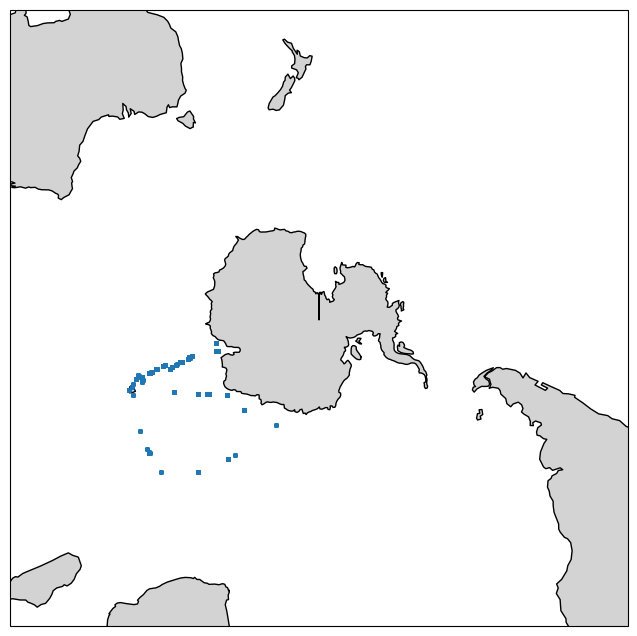

In [60]:
# Plot a polar stereographic map of all profiles
plt.figure(figsize=(8,8))
import cartopy.crs as ccrs
import cartopy.feature as cfeature
ax = plt.axes(projection=ccrs.Stereographic(central_latitude=-90, central_longitude=180))
ax.set_extent([-180, 180, -90, -30], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='lightgray')
sc = ax.scatter(comparison_all_profiles_pre2023['Lon'], comparison_all_profiles_pre2023['Lat'], transform=ccrs.PlateCarree(),s=5)

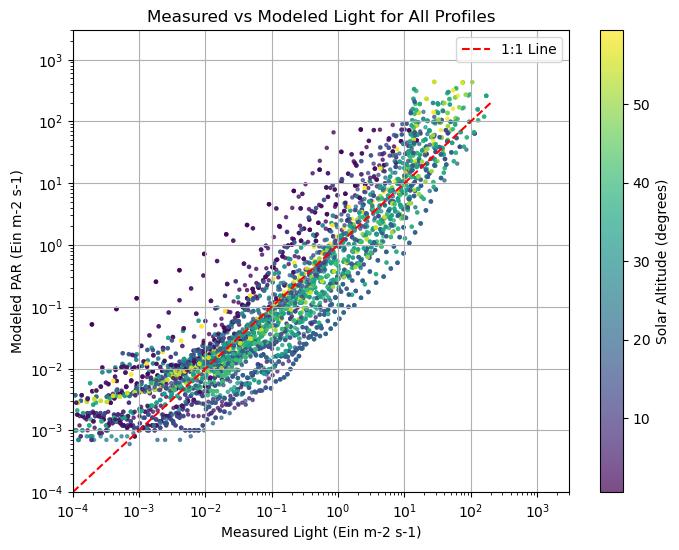

Light Linear Model: Slope=1.918, Intercept=1.478, R2=0.451, RMSE=26.6580, p=0.671


In [81]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_pre2023['Light_measured'], comparison_all_profiles_pre2023['PAR_modeled'], c=comparison_all_profiles_pre2023['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 3000)
plt.ylim(1e-4, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
from sklearn.metrics import r2_score, mean_squared_error
import math
light_measured = comparison_all_profiles_pre2023['Light_measured'].values
par_modeled = comparison_all_profiles_pre2023['PAR_modeled'].values
# Remove nans
valid_idx = ~np.isnan(light_measured) & ~np.isnan(par_modeled)
light_measured = light_measured[valid_idx]
par_modeled = par_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(light_measured, par_modeled, 1)
par_modeled_pred = slope * light_measured + intercept
r2 = r2_score(par_modeled, par_modeled_pred)
rmse = math.sqrt(mean_squared_error(par_modeled, par_modeled_pred))
p_value = np.corrcoef(light_measured, par_modeled)[0,1]
print('Light Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

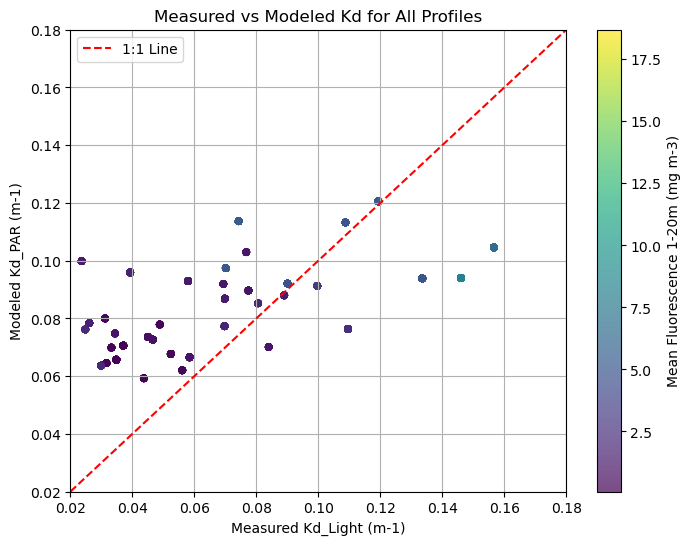

Kd Linear Model: Slope=0.193, Intercept=0.070, R2=0.326, RMSE=0.0125 m-1, p=0.571


In [63]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_pre2023['Kd_measured_1_20m'], comparison_all_profiles_pre2023['Kd_modeled_1_20m'], c=comparison_all_profiles_pre2023['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled Kd
from sklearn.metrics import r2_score, mean_squared_error
import math
kd_measured = comparison_all_profiles_pre2023['Kd_measured_1_20m'].values
kd_modeled = comparison_all_profiles_pre2023['Kd_modeled_1_20m'].values
# Remove nans
valid_idx = ~np.isnan(kd_measured) & ~np.isnan(kd_modeled)
kd_measured = kd_measured[valid_idx]
kd_modeled = kd_modeled[valid_idx]
# Linear regression
slope, intercept = np.polyfit(kd_measured, kd_modeled, 1)
kd_modeled_pred = slope * kd_measured + intercept
r2 = r2_score(kd_modeled, kd_modeled_pred)
rmse = math.sqrt(mean_squared_error(kd_modeled, kd_modeled_pred))
p_value = np.corrcoef(kd_measured, kd_modeled)[0,1]
print('Kd Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f} m-1, p={:.3f}'.format(slope, intercept, r2, rmse, p_value))

### ct182 and 2018–2023 combined

In [72]:
def type2_regression_complete(x, y):
    """
    Complete Type 2 regression with multiple regression types
    Similar to R's lmodel2 package
    """
    valid_idx = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_idx]
    y_clean = y[valid_idx]
    
    n = len(x_clean)
    
    # Basic statistics
    x_mean = np.mean(x_clean)
    y_mean = np.mean(y_clean)
    sx = np.std(x_clean, ddof=1)  # sample standard deviation
    sy = np.std(y_clean, ddof=1)
    r = np.corrcoef(x_clean, y_clean)[0, 1]
    
    # Different regression types
    results = {}
    
    # 1. Ordinary Least Squares (OLS) - Type 1
    slope_ols = r * sy / sx
    intercept_ols = y_mean - slope_ols * x_mean
    results['OLS'] = (slope_ols, intercept_ols)
    
    # 2. Major Axis (MA) - Type 2
    slope_ma = np.sign(r) * sy / sx
    intercept_ma = y_mean - slope_ma * x_mean
    results['MA'] = (slope_ma, intercept_ma)
    
    # 3. Standard Major Axis (SMA) - same as MA
    results['SMA'] = results['MA']
    
    # 4. Reduced Major Axis (RMA) - another name for MA
    results['RMA'] = results['MA']
    
    # Calculate fit statistics
    y_pred_ma = slope_ma * x_clean + intercept_ma
    r2 = r**2
    rmse = np.sqrt(np.mean((y_clean - y_pred_ma)**2))
    
    return results, r2, rmse, r, n

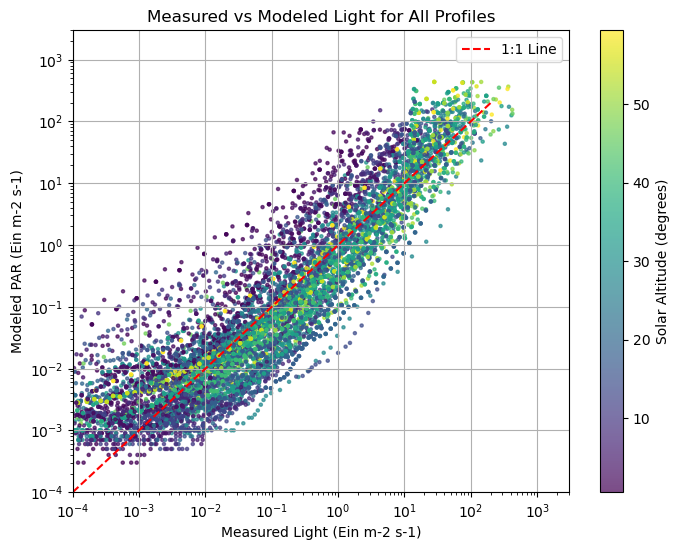

Light Type 2 Linear Model: Slope=1.082, Intercept=3.460, R2=0.398, RMSE=28.1771


In [82]:
# Scatter plot of measured vs modeled light for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Light_measured'], comparison_all_profiles_ct182['PAR_modeled'], c=comparison_all_profiles_ct182['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
sc = plt.scatter(comparison_all_profiles_pre2023['Light_measured'], comparison_all_profiles_pre2023['PAR_modeled'], c=comparison_all_profiles_pre2023['SolarAlt'], cmap='viridis', alpha=0.7, s=5)
plt.colorbar(sc, label='Solar Altitude (degrees)')
plt.plot([1e-4, 200], [1e-4, 200], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Light (Ein m-2 s-1)')
plt.ylabel('Modeled PAR (Ein m-2 s-1)')
plt.title('Measured vs Modeled Light for All Profiles')
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-4, 3000)
plt.ylim(1e-4, 3000)
plt.show()

# Display linear model statistics between measured and modeled light
results, r2, rmse, r, n = type2_regression_complete(
    np.concatenate([comparison_all_profiles_pre2023['Light_measured'].values, comparison_all_profiles_ct182['Light_measured'].values]),
    np.concatenate([comparison_all_profiles_pre2023['PAR_modeled'].values, comparison_all_profiles_ct182['PAR_modeled'].values])
)

slope_type2, intercept_type2 = results['OLS']
r2 = r2
rmse = rmse
r = r

print('Light Type 2 Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}'.format(slope_type2, intercept_type2, r2, rmse, r))

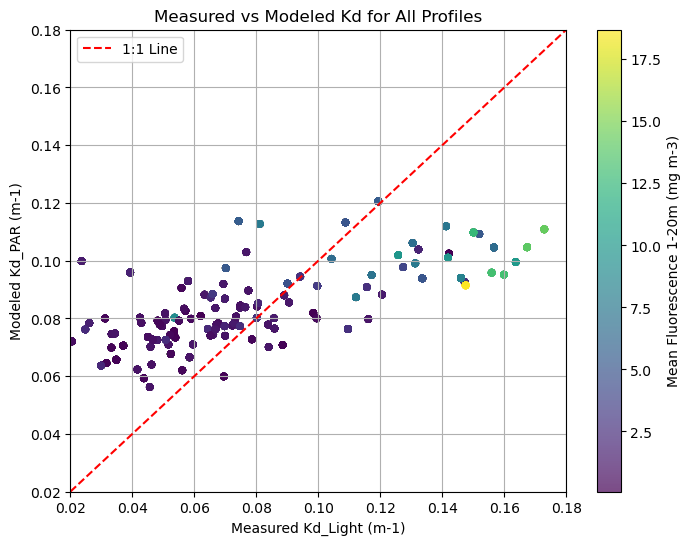

Light Type 2 Linear Model: Slope=0.208, Intercept=0.068, R2=0.421, RMSE=0.0119


In [84]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['Kd_measured_1_20m'], comparison_all_profiles_ct182['Kd_modeled_1_20m'], c=comparison_all_profiles_ct182['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
sc = plt.scatter(comparison_all_profiles_pre2023['Kd_measured_1_20m'], comparison_all_profiles_pre2023['Kd_modeled_1_20m'], c=comparison_all_profiles_pre2023['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled light
results, r2, rmse, r, n = type2_regression_complete(
    np.concatenate([comparison_all_profiles_pre2023['Kd_measured_1_20m'].values, comparison_all_profiles_ct182['Kd_measured_1_20m'].values]),
    np.concatenate([comparison_all_profiles_pre2023['Kd_modeled_1_20m'].values, comparison_all_profiles_ct182['Kd_modeled_1_20m'].values])
)

slope_type2, intercept_type2 = results['OLS']
r2 = r2
rmse = rmse
r = r

print('Light Type 2 Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}'.format(slope_type2, intercept_type2, r2, rmse, r))

In [ ]:
# Scatter plot of measured vs modeled Kd for all profiles (log log scale)
plt.figure(figsize=(8,6))
sc = plt.scatter(comparison_all_profiles_ct182['SlopeFactor'], comparison_all_profiles_ct182['SlopeFactor'], c=comparison_all_profiles_ct182['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
sc = plt.scatter(comparison_all_profiles_pre2023['SlopeFactor'], comparison_all_profiles_pre2023['SlopeFactor'], c=comparison_all_profiles_pre2023['Fluo_measured_mean_1_20m'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(sc, label='Mean Fluorescence 1-20m (mg m-3)')
plt.plot([0.02, 0.18], [0.02, 0.18], 'r--', label='1:1 Line')
plt.legend()
plt.xlabel('Measured Kd_Light (m-1)')
plt.ylabel('Modeled Kd_PAR (m-1)')
plt.title('Measured vs Modeled Kd for All Profiles')
plt.grid()
# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0.02, 0.18)
plt.ylim(0.02, 0.18)
plt.show()

# Display linear model statistics between measured and modeled light
results, r2, rmse, r, n = type2_regression_complete(
    np.concatenate([comparison_all_profiles_pre2023['Kd_measured_1_20m'].values, comparison_all_profiles_ct182['Kd_measured_1_20m'].values]),
    np.concatenate([comparison_all_profiles_pre2023['Kd_modeled_1_20m'].values, comparison_all_profiles_ct182['Kd_modeled_1_20m'].values])
)

slope_type2, intercept_type2 = results['OLS']
r2 = r2
rmse = rmse
r = r

print('Light Type 2 Linear Model: Slope={:.3f}, Intercept={:.3f}, R2={:.3f}, RMSE={:.4f}'.format(slope_type2, intercept_type2, r2, rmse, r))